# Nettoyage de nos données

Importons les packages qui nous seront utiles dans ce travail

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.impute import KNNImputer
import scipy.stats as stats
from matplotlib.ticker import FuncFormatter
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer

# Valeurs manquantes 
import missingno as msno 


Importons dès à présent les données

In [2]:
df = pd.read_csv("data/home_data.csv", delimiter=";", index_col=0)

<Axes: >

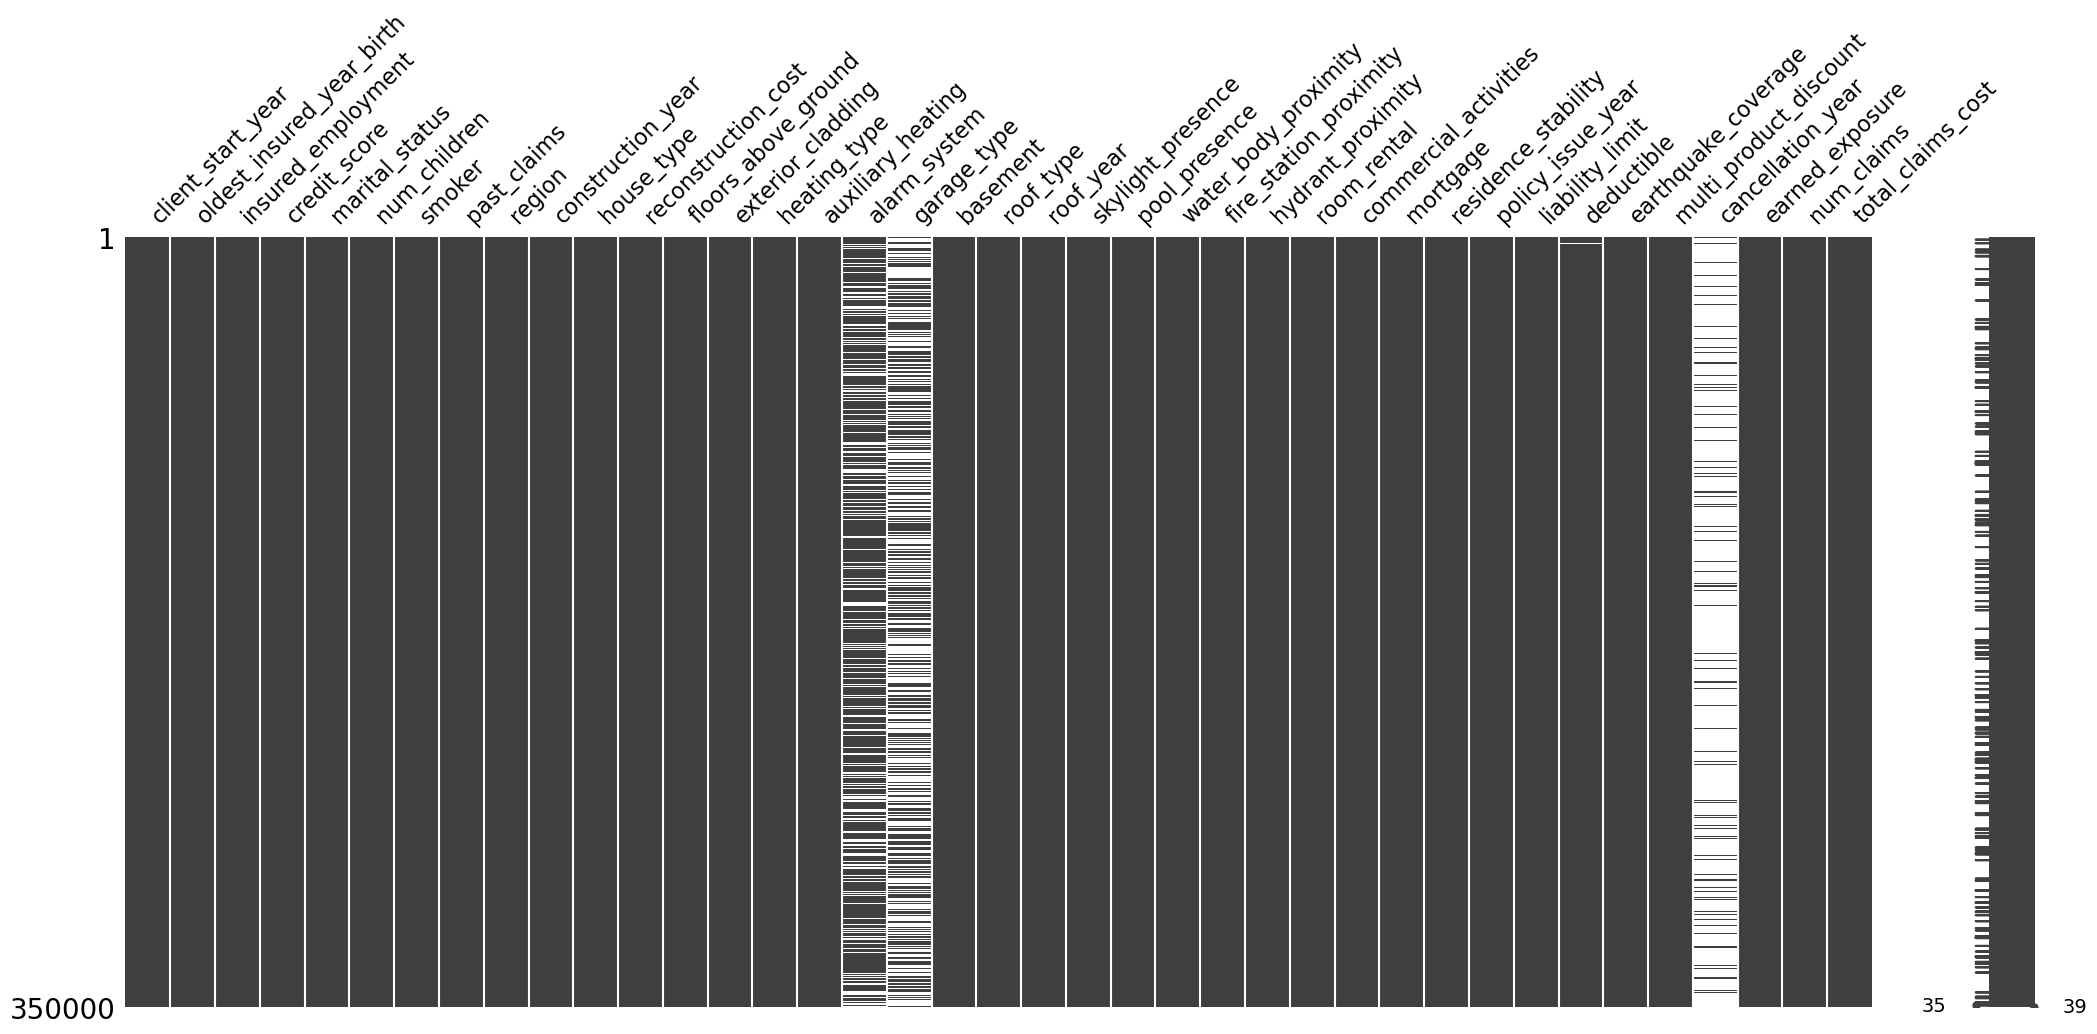

In [5]:
msno.matrix(df)

### Résumé des données

In [6]:
# Fonction pour obtenir les statistiques descriptives des variables des données
def summarize_df(Dataframe):

    summary = pd.DataFrame()

    # Type de données 
    summary["Data Type"] = Dataframe.dtypes

    # Nombre de valeur uniques
    summary["Unique values"] = Dataframe.nunique()

    # Les valeurs uniques 
    summary["Unique"] = Dataframe.apply(lambda x: x.unique().tolist())

    # Maximum
    summary["Max"] = Dataframe.apply(lambda x: x.max() if pd.api.types.is_numeric_dtype(x) else "-")

    # Minimum 
    summary["Min"] = Dataframe.apply(lambda x: x.min() if pd.api.types.is_numeric_dtype(x) else "-")

    # Moyenne, Médiane, Mode
    summary["Mean"] = Dataframe.apply(lambda x: round(x.mean(), 4) if pd.api.types.is_numeric_dtype(x) else "-")
    summary["Median"] = Dataframe.apply(lambda x: x.median() if pd.api.types.is_numeric_dtype(x) else "-")
    summary["Mode"] = Dataframe.apply(lambda x: x.mode().iloc[0] if pd.api.types.is_numeric_dtype(x) else "-")

    # Mesures de dispersion
    summary["Range"] = Dataframe.apply(lambda x: x.max() - x.min() if pd.api.types.is_numeric_dtype(x) else "-")
    summary["Variance"] = Dataframe.apply(lambda x: x.var() if pd.api.types.is_numeric_dtype(x) else "-")
    summary["Range"] = Dataframe.apply(lambda x: x.std() if pd.api.types.is_numeric_dtype(x) else "-")

    # Mesures de la forme de la distribution 
    summary["Skewness"] = Dataframe.apply(lambda x: round(x.skew(), 4) if pd.api.types.is_numeric_dtype(x) else "-")
    summary["Kurtosis"] = Dataframe.apply(lambda x: round(x.kurt(), 4) if pd.api.types.is_numeric_dtype(x) else "-")

    return summary

In [7]:
summary = summarize_df(df)
summary

,Data Type,Unique values,Unique,Max,Min,Mean,Median,Mode,Range,Variance,Skewness,Kurtosis
client_start_year,int64,16,"[2019, 2013, 2014, 2017, 2020, 2018, 2016, 202...",2023,0,1996.2819,2016.0,2019,199.793398,39917.402064,-9.8887,95.8174
oldest_insured_year_birth,int64,78,"[1988, 1941, 1992, 1991, 1989, 1953, 1973, 197...",2005,0,1947.2539,1967.0,1957,197.107833,38851.497889,-9.665,92.5272
insured_employment,object,7,"[Healthcare, Unemployed, Other, Retired, Publi...",-,-,-,-,-,-,-,-,-
credit_score,int64,737,"[687, 543, 778, 699, 388, 796, 808, 798, 826, ...",9999,250,1056.0363,785.0,9999,1652.163058,2729642.770737,5.1804,25.1075
marital_status,object,4,"[Married, Divorced, Single, Widowed]",-,-,-,-,-,-,-,-,-
num_children,int64,6,"[1, 3, 2, 4, 0, 5]",5,0,2.2234,2.0,2,1.402589,1.967257,0.1854,-0.7357
smoker,object,2,"[No, Yes]",-,-,-,-,-,-,-,-,-
past_claims,int64,4,"[0, 3, 1, 2]",3,0,0.1192,0.0,0,0.451454,0.203811,4.3461,20.0008
region,object,12,"[Estrie, Laval, Quebec City, Outaouais, Lauren...",-,-,-,-,-,-,-,-,-
construction_year,float64,119,"[1934.0, 2012.0, 1996.0, 1940.0, 1981.0, 1988....",2018.0,1900.0,1958.9696,1959.0,1961.0,34.342285,1179.392523,-0.0,-1.1991


- **client_start_year** : On a un minimum de 0 qui est aberrant.
- **odlest_insured_year_birth** : même cas pour le minimum.
- **credit_score** : un maximum de 9999 est alarmant
- **roof_year** : la présence d'année 0 n'est pas normale
- **earned_exposure** : présence d'expositions acquises négatives
- **total_claims_cost** : présence de coûts négatifs

#### Relation entre **total_claims_cost** et **num_claims**

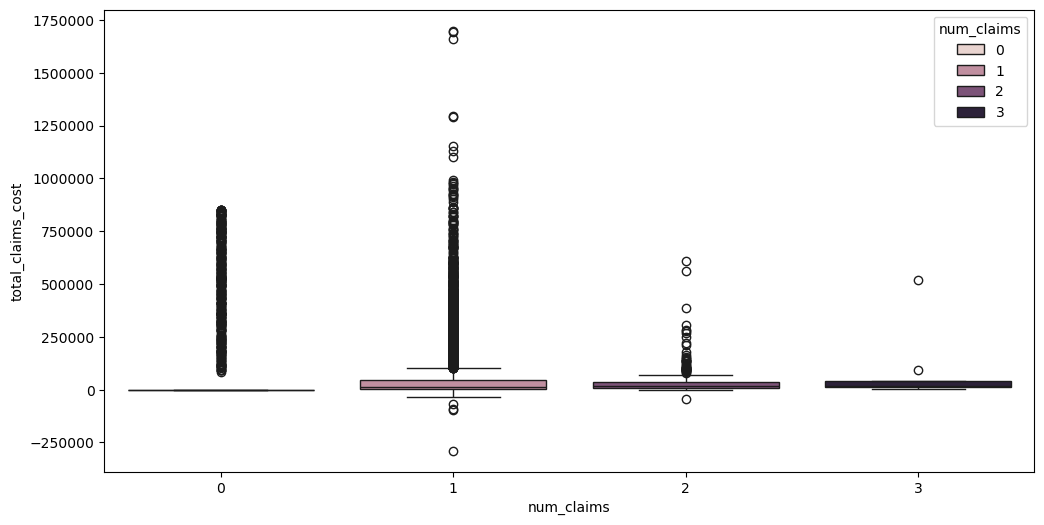

In [3]:
plt.figure(figsize=(12, 6))
sns.boxplot(data=df, x= "num_claims", y="total_claims_cost", hue="num_claims")
plt.ticklabel_format(style='plain', axis='y')

On constante la présence de coûts négatifs mais aussi des coûts nuls lorsqu'il y a réclamation. On a également la présence de coûts pour des cas sans réclamations.

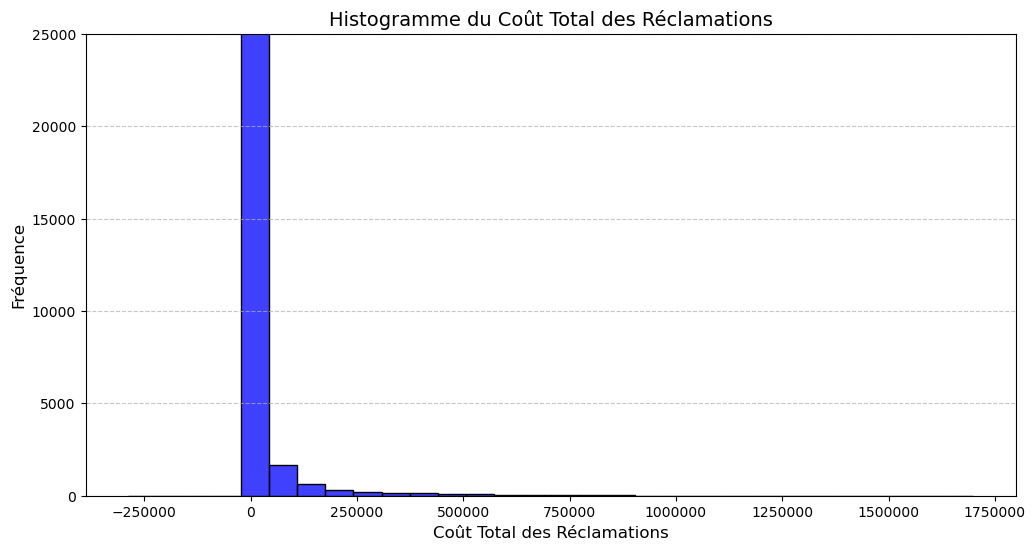

In [4]:
# Tracer l'histogramme de total_claims_cost
plt.figure(figsize=(12, 6))
sns.histplot(df['total_claims_cost'], bins=30, kde=False, color='blue')  # kde=True pour ajouter une courbe de densité
plt.xlabel('Coût Total des Réclamations', fontsize=12)
plt.ylabel('Fréquence', fontsize=12)
plt.title("Histogramme du Coût Total des Réclamations", fontsize=14)
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Désactiver la notation scientifique sur l'axe des x
plt.ticklabel_format(style='plain', axis='x')
plt.ylim(0, 25000);

L'analyse de ces 2 graphiques permet de remarquer qu'il existe des montants de sinistres déclarés négatifs. On pourrait donc penser ici qu'il s'agit d'une erreur de saisie et donc retirer le signe négatif de ses observations. Le code ci-dessous montre cette erreur concerne **15** observations de nos données

In [8]:
(df['total_claims_cost'] < 0).sum()

np.int64(15)

In [9]:
df[df['total_claims_cost'] < 0] = - 1 * df[df['total_claims_cost'] < 0]

On remarque qu'il existe des cas où il n'y a pas de sinistres déclarés mais on observe des montants de sinistres et des cas où il existe des sinistres déclarés mais pas de montants déclarés

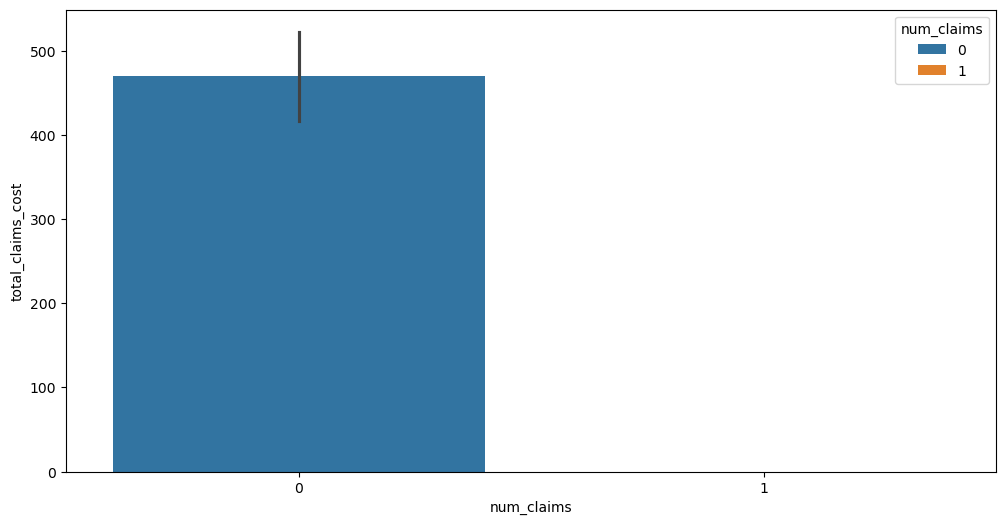

In [10]:
# Filtrer le DataFrame pour inclure uniquement les cas où num_claims et total_claims_cost sont tous les deux égaux à 0
df_filtered = df[(df['num_claims'] == 0) | (df['total_claims_cost'] == 0)]

# Tracer le graphique avec les données filtrées
plt.figure(figsize=(12, 6))
sns.barplot(data=df_filtered, x="num_claims", y="total_claims_cost", hue="num_claims")
plt.ticklabel_format(style='plain', axis='y')
plt.show()


- **Des sinistres déclarés mais pas de montants de sinistres**:
Ces observations représentent 0.1% de nos données ce qui est très faible donc on pourrait les supprimer.

In [11]:
((df['total_claims_cost'] == 0) & (df['num_claims'] > 0)).sum()/len(df) * 100

np.float64(0.1)

In [12]:
df = df[~((df['total_claims_cost'] == 0) & (df['num_claims'] > 0))]

- **Des montants de sinistres déclarés mais pas de nombre de sinistres**

L'objectif de cette imputation est de corriger les valeurs de `num_claims` pour les enregistrements où le coût total des sinistres (`total_claims_cost`) est supérieur à 0, mais où le nombre de sinistres (`num_claims`) est égal à 0.  
Une telle situation est incohérente, car un coût de sinistres positif devrait correspondre à **au moins un sinistre**.

#### **Stratégie d’imputation :**

1. Identifier les lignes où `total_claims_cost` est supérieur à 0 et `num_claims` est égal à 0.  
2. Remplacer `num_claims` pour ces lignes par une estimation basée sur le coût moyen des sinistres.  

La formule utilisée est la suivante :

$$
\text{num\_claims}_i = \left\lceil \frac{\text{total\_claims\_cost}_i}{\text{moyenne\_total\_claims\_cost}} \right\rceil
$$

où :

- `total_claims_cost_i` : coût total des sinistres pour l’enregistrement *i*.  
- `moyenne_total_claims_cost` : moyenne de `total_claims_cost` pour toutes les lignes sélectionnées (celles où `total_claims_cost > 0` et `num_claims = 0`).  
- `np.ceil` : fonction d’arrondi à l’entier supérieur, assurant qu’il y ait **au moins un sinistre** pour tout coût positif.


**Résultat attendu :**
En appliquant cette imputation, on obtient une **estimation du nombre de sinistres cohérente** avec les coûts associés, corrigeant ainsi les valeurs incohérentes de `num_claims` initialement à zéro.
ement à zéro.


In [13]:
# Filtrer les lignes où total_claims_cost > 0 et num_claims == 0
condition = (df['total_claims_cost'] > 0) & (df['num_claims'] == 0)

# Calculer la moyenne de total_claims_cost pour les lignes correspondant à la condition
mean_cost = df.loc[condition, 'total_claims_cost'].mean()

# Imputer num_claims pour ces lignes en divisant total_claims_cost par mean_cost et en arrondissant à l'entier supérieur
df.loc[condition, 'num_claims'] = np.ceil(df.loc[condition, 'total_claims_cost'] / mean_cost)

#### Explorons les données manquantes 

On se fixera ici un seuil de 1% pour lequel si 1% de nos observations sont des données manquantes, on jugera acceptable de les supprimer

In [14]:
missing_percent = 100 * df.isnull().sum() / len(df)
missing_percent = missing_percent[missing_percent != 0]
missing_percent

construction_year     0.088088
heating_type          0.098384
alarm_system         24.994709
garage_type          52.139568
liability_limit       0.110682
deductible            0.095810
cancellation_year    89.929644
dtype: float64

- La colonne **cancellation_year** contient 89% de données manquantes par rapport à nos observations. On considère que les données manquantes indiquent que les contrats n'ont pas été résiliés. On les remplace donc par 0.

In [15]:
df['cancellation_year'] = df['cancellation_year'].fillna(0)

In [16]:
df['cancellation_year'].value_counts()

cancellation_year
 0.0       314439
 2019.0      7176
 2021.0      7051
 2023.0      7025
 2020.0      7001
 2022.0      6956
-2021.0         1
-2023.0         1
Name: count, dtype: int64

In [17]:
df['cancellation_year'] = df["cancellation_year"].abs()
df['cancellation_year'].value_counts()

cancellation_year
0.0       314439
2019.0      7176
2021.0      7052
2023.0      7026
2020.0      7001
2022.0      6956
Name: count, dtype: int64

- Cas des features dont les valeurs manquantes sont inférieures à 1%

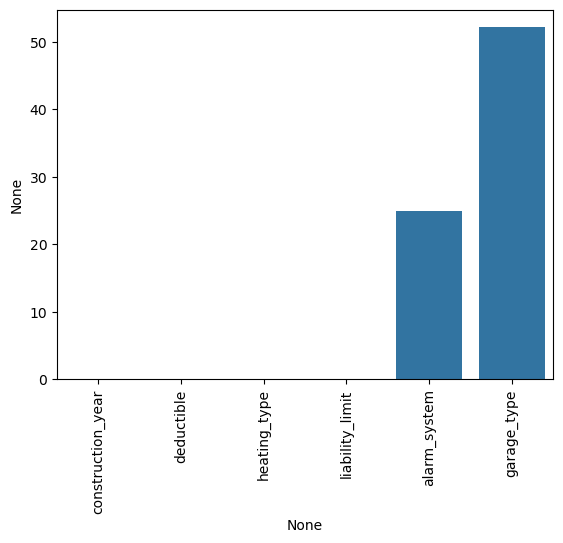

In [19]:
def percent_missing(df):
    percent_nan = 100* df.isnull().sum() / len(df)
    percent_nan = percent_nan[percent_nan>0].sort_values()
    return percent_nan

percent_nan = percent_missing(df)

sns.barplot(x=percent_nan.index,y=percent_nan)
plt.xticks(rotation=90);

1. **deductible**

Il existe des données négatives donc on retire le signe négatif en multipliant par -1.

Les données manquantes quant à elle sont supprimées étant donné leur faible proportion

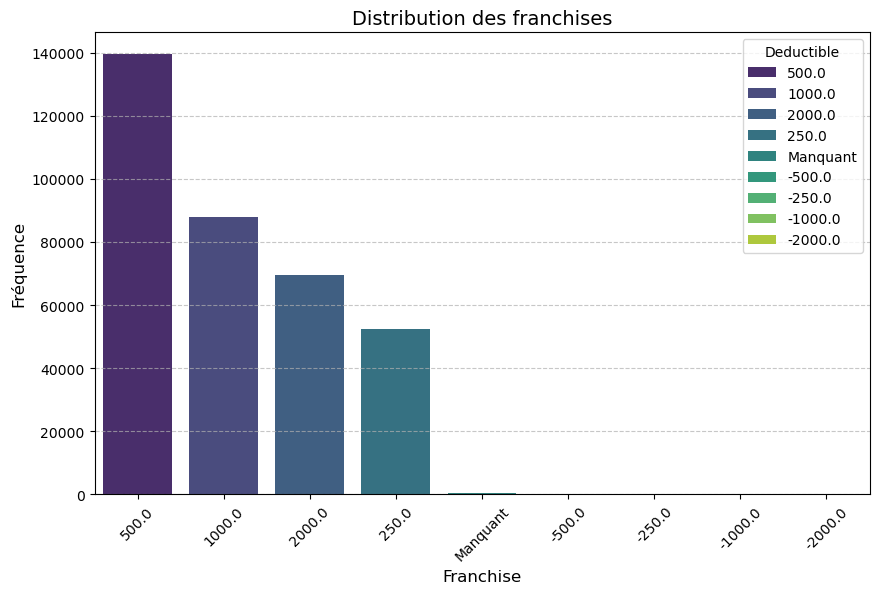

In [20]:
# Créer une copie temporaire de la colonne 'deductible' avec les NaN remplacés
temp_deductible = df['deductible'].fillna('Manquant')

# Comptage des différentes valeurs de deductible, y compris les NaN remplacés
deductible_counts = temp_deductible.value_counts().reset_index()

# Renommer les colonnes
deductible_counts.columns = ['Deductible', 'Count']

# Tracer le graphique à barres avec Seaborn
plt.figure(figsize=(10, 6))
sns.barplot(x='Deductible', y='Count', data=deductible_counts, hue= "Deductible", palette='viridis')
plt.xlabel('Franchise', fontsize=12)
plt.ylabel('Fréquence', fontsize=12)
plt.title('Distribution des franchises', fontsize=14)
plt.xticks(rotation=45)  # Incliner les labels sur l'axe x si nécessaire
plt.grid(axis='y', linestyle='--', alpha=0.7)

In [21]:
# Changer le signe des observations négatives
df[df["deductible"]< 0 ] = - 1 * df[df["deductible"]< 0 ]

In [22]:
# Supprimer les observations manquantes
df.dropna(subset=['deductible'], inplace=True)

2. **construction_year**

In [23]:
df["construction_year"].unique()

array([1934., 2012., 1996., 1940., 1981., 1988., 1971., 1968., 1902.,
       1953., 2007., 2016., 1931., 1985., 1961., 1943., 1984., 1986.,
       2005., 1956., 1911., 2018., 1900., 1926., 1995., 1913., 1924.,
       2001., 1982., 1919., 2013., 1922., 2010., 1958., 1915., 1975.,
       1973., 1907., 1912., 2014., 1992., 1987., 1990., 1980., 1933.,
       1999., 1918., 1966., 1948., 1944., 1935., 1938., 1942., 1927.,
       2009., 1905., 1979., 2000., 1939., 1977., 1901., 1967., 1947.,
       1994., 1941., 1950., 1908., 1957., 1998., 1993., 1949., 2006.,
       1929., 1904., 2008., 1923., 2004., 1916., 1952., 1951., 2017.,
       2011., 2015., 1963., 1989., 1914., 1976., 1997., 1917., 1906.,
       1910., 1974., 1970., 1937., 1946., 1925., 1991., 1959., 1921.,
       1978., 1960., 1936., 1930., 1965., 1972., 1983., 1945., 1920.,
       1903., 1962., 1928., 1954., 1955., 1969., 1964., 2003., 2002.,
       1932., 1909.,   nan])

In [24]:
# suppression des données manquantes
df.dropna(subset=["construction_year"], inplace=True)

3. **heating_type**

In [25]:
df["heating_type"].unique()

array(['Electricity', 'Gas/Oil', 'Other', 'Wood', nan, ''], dtype=object)

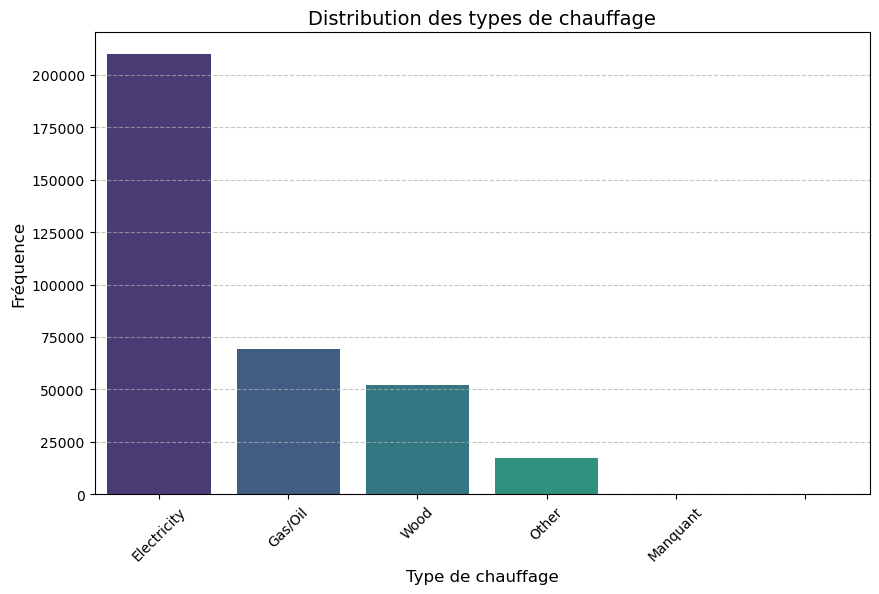

In [26]:
# Créer une copie temporaire de la colonne 'heating_type' avec les NaN remplacés
temp_heating_type = df['heating_type'].fillna('Manquant')

# Comptage des différentes valeurs de heating_type, y compris les NaN remplacés
heating_type_counts = temp_heating_type.value_counts().reset_index()

# Renommer les colonnes
heating_type_counts.columns = ['Heating Type', 'Count']

# Tracer le graphique à barres avec Seaborn
plt.figure(figsize=(10, 6))
sns.barplot(x='Heating Type', y='Count', data=heating_type_counts, hue="Heating Type", palette='viridis')
plt.xlabel('Type de chauffage', fontsize=12)
plt.ylabel('Fréquence', fontsize=12)
plt.title('Distribution des types de chauffage', fontsize=14)
plt.xticks(rotation=45)  # Incliner les labels sur l'axe x si nécessaire
plt.grid(axis='y', linestyle='--', alpha=0.7)

In [27]:
# Suppression des données manquantes
df.dropna(subset=['heating_type'], inplace=True)

On observe des données dont la valeur n'est pas rentrée. On pourrait donc penser qu'il s'agit de cas où le type de chauffage n'était pas dans la liste donc c'est observations concernent surement la catégorie Other

In [28]:
df['heating_type'] = df['heating_type'].replace('', 'Other')

- **liability_limit**

In [29]:
df['liability_limit'].unique()

array(['2M', '1M', nan, ''], dtype=object)

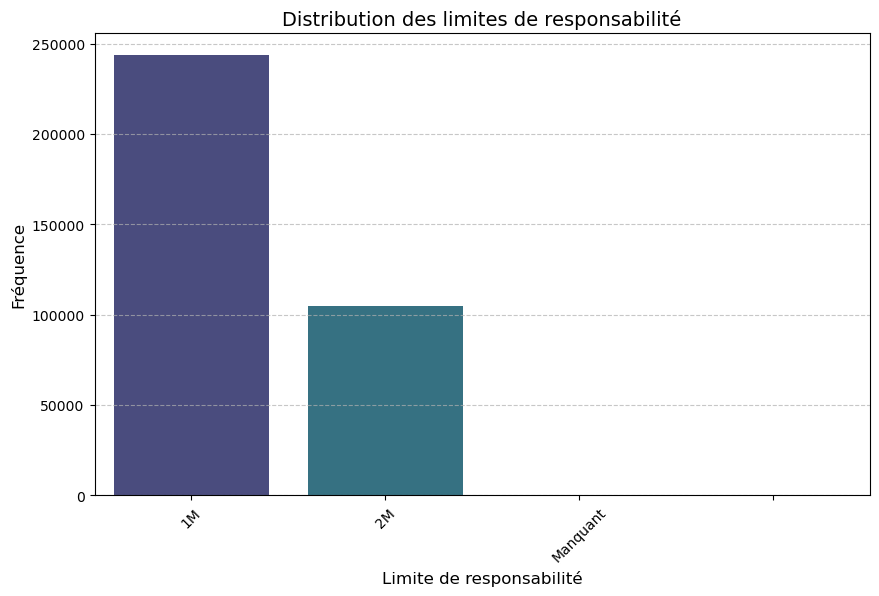

In [30]:
# Créer une copie temporaire de la colonne 'liability_limit' avec les NaN remplacés
temp_liability_limit = df['liability_limit'].fillna('Manquant')

# Comptage des différentes valeurs de liability_limit, y compris les NaN remplacés
liability_limit_counts = temp_liability_limit.value_counts().reset_index()

# Renommer les colonnes
liability_limit_counts.columns = ['Liability Limit', 'Count']

# Tracer le graphique à barres avec Seaborn
plt.figure(figsize=(10, 6))
sns.barplot(x='Liability Limit', y='Count', data=liability_limit_counts, hue="Liability Limit", palette='viridis')
plt.xlabel('Limite de responsabilité', fontsize=12)
plt.ylabel('Fréquence', fontsize=12)
plt.title('Distribution des limites de responsabilité', fontsize=14)
plt.xticks(rotation=45)  # Incliner les labels sur l'axe x si nécessaire
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()


Ici les valeurs manquantes et les valeurs vides peuvent laisser penser qu'il s'agit de maison donc le contrat d'assurance n'a pas de limite fixée ce qui est en pratique impossible. Ces données représentent 0.11% de nos observations ce qui est inférieur à notre seuil fixé donc il serait préférable de les exclure au lieu d'ajouter une nouvelle catégorie.

In [31]:
df['liability_limit'] = df['liability_limit'].replace("", np.nan)

df.dropna(axis=0, subset=['liability_limit'], inplace=True)

- **alarm_system**

In [32]:
df['alarm_system'].unique()

array(['Fire only', 'Fire and Theft', 'Theft only', nan], dtype=object)

Ici les données manquantes de la feature représente 25% de nos observations donc nous devons trouver une méthode d'imputation. Rappellons nous que toute les maisons n'ont pas obligatoirement un système d'alarme donc les valeurs manquantes ici serait sûrement là pour catégoriser ce type de maison. Nous allons donc remplacer les valeurs manquantes par une nouvelle catégorie.

In [33]:
df['alarm_system'] = df['alarm_system'].fillna("No alarm system")

- **garage_type**


In [34]:
df["garage_type"].unique()

array(['1 car', nan], dtype=object)

Ici, les valeurs manquantes représentent plus de 50% de nos observations. Prenons le contexte d'habitation au Canada. Toutes les maisons n'ont pas forcément un garage inclus. Les propriétaires qui ont un véhicule utilisent donc un stationnement extérieur dans la rue ou dans un parking privé. En général on a donc la possibilité qu'il y ait un garage pour 1 voiture ou qu'il n'y ait pas de garage donc on pourrait transformer cette variable en variable indicatrice.

In [35]:
df["garage_type"] = df["garage_type"].fillna("No garage")

In [36]:
# Vérifions si on a traité toutes les données manquantes
percent_missing(df)

Series([], dtype: float64)

<Axes: >

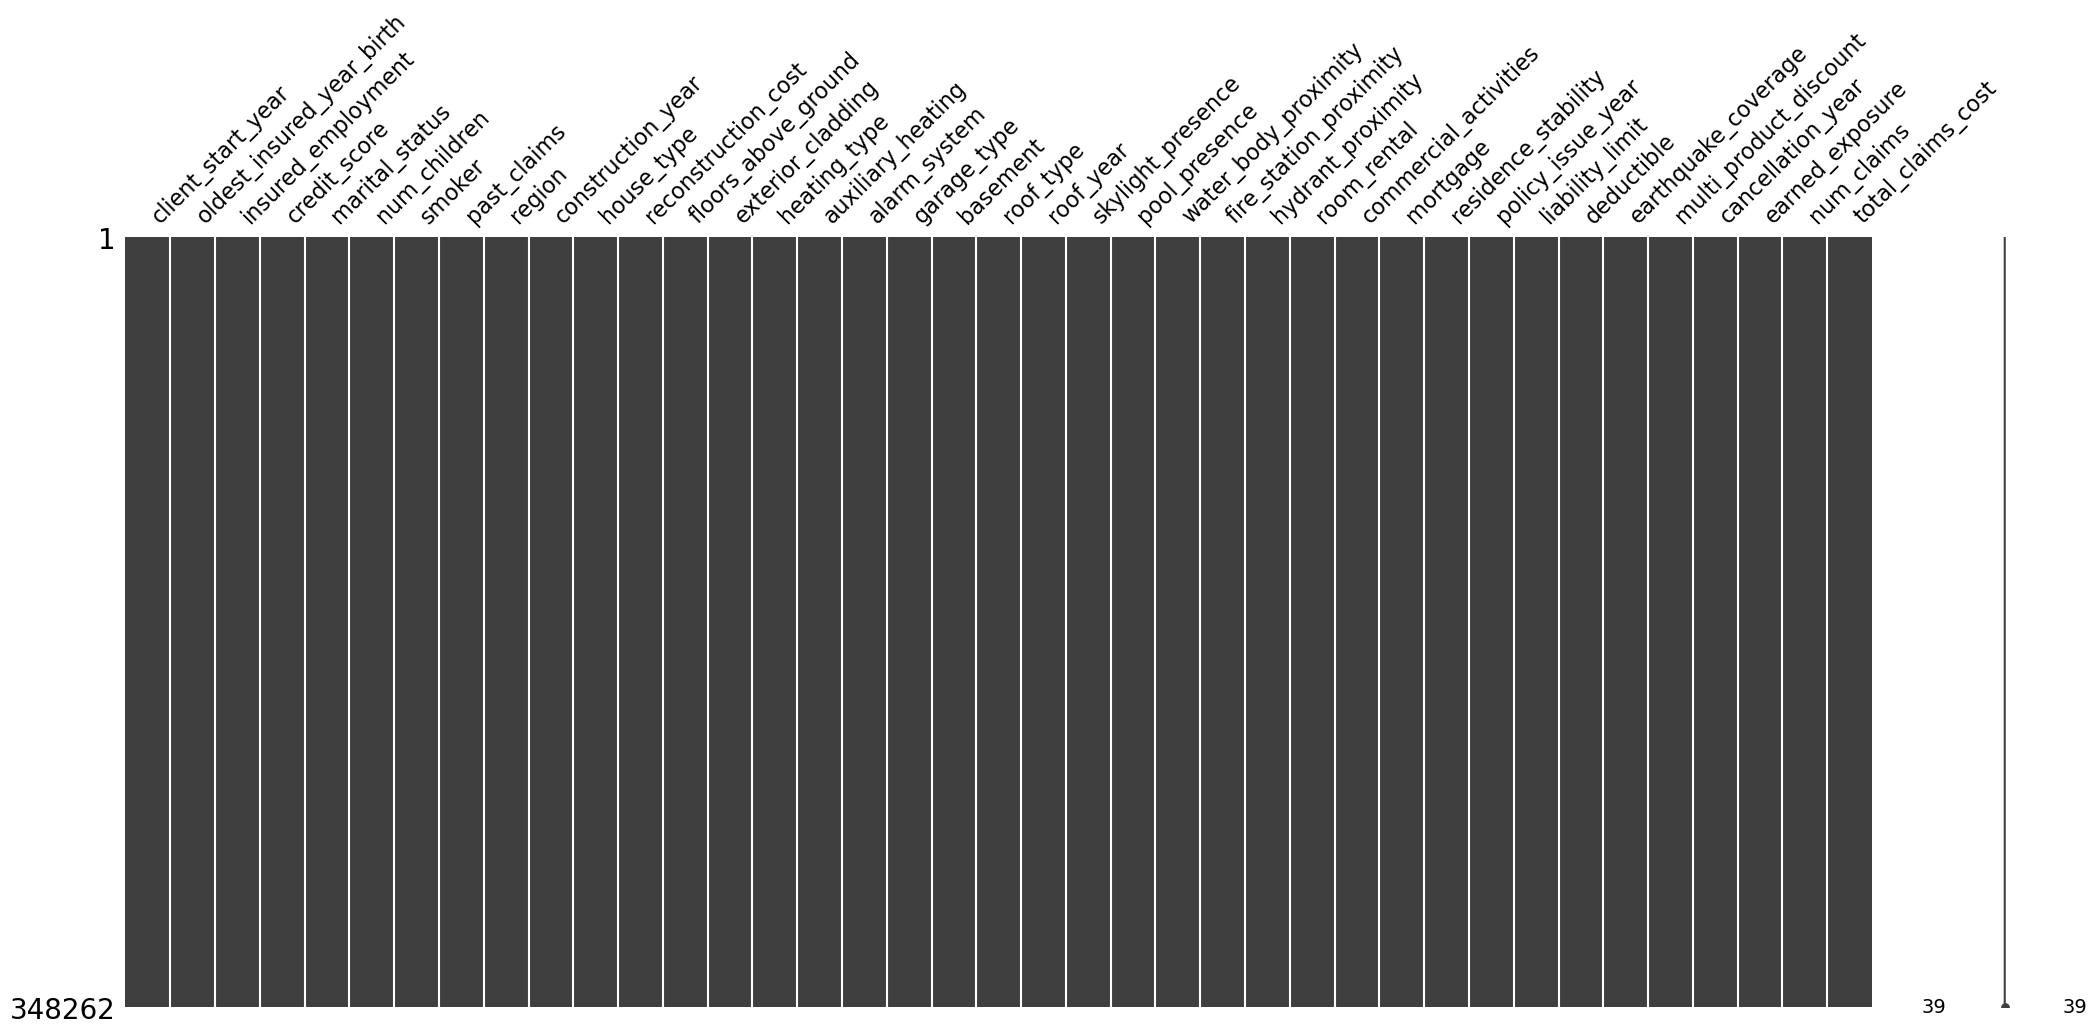

In [37]:
msno.matrix(df)

Toutes les données manquantes ont été traitées, passons aux données abérrantes ou outliers

#### Données abérrantes ou outliers

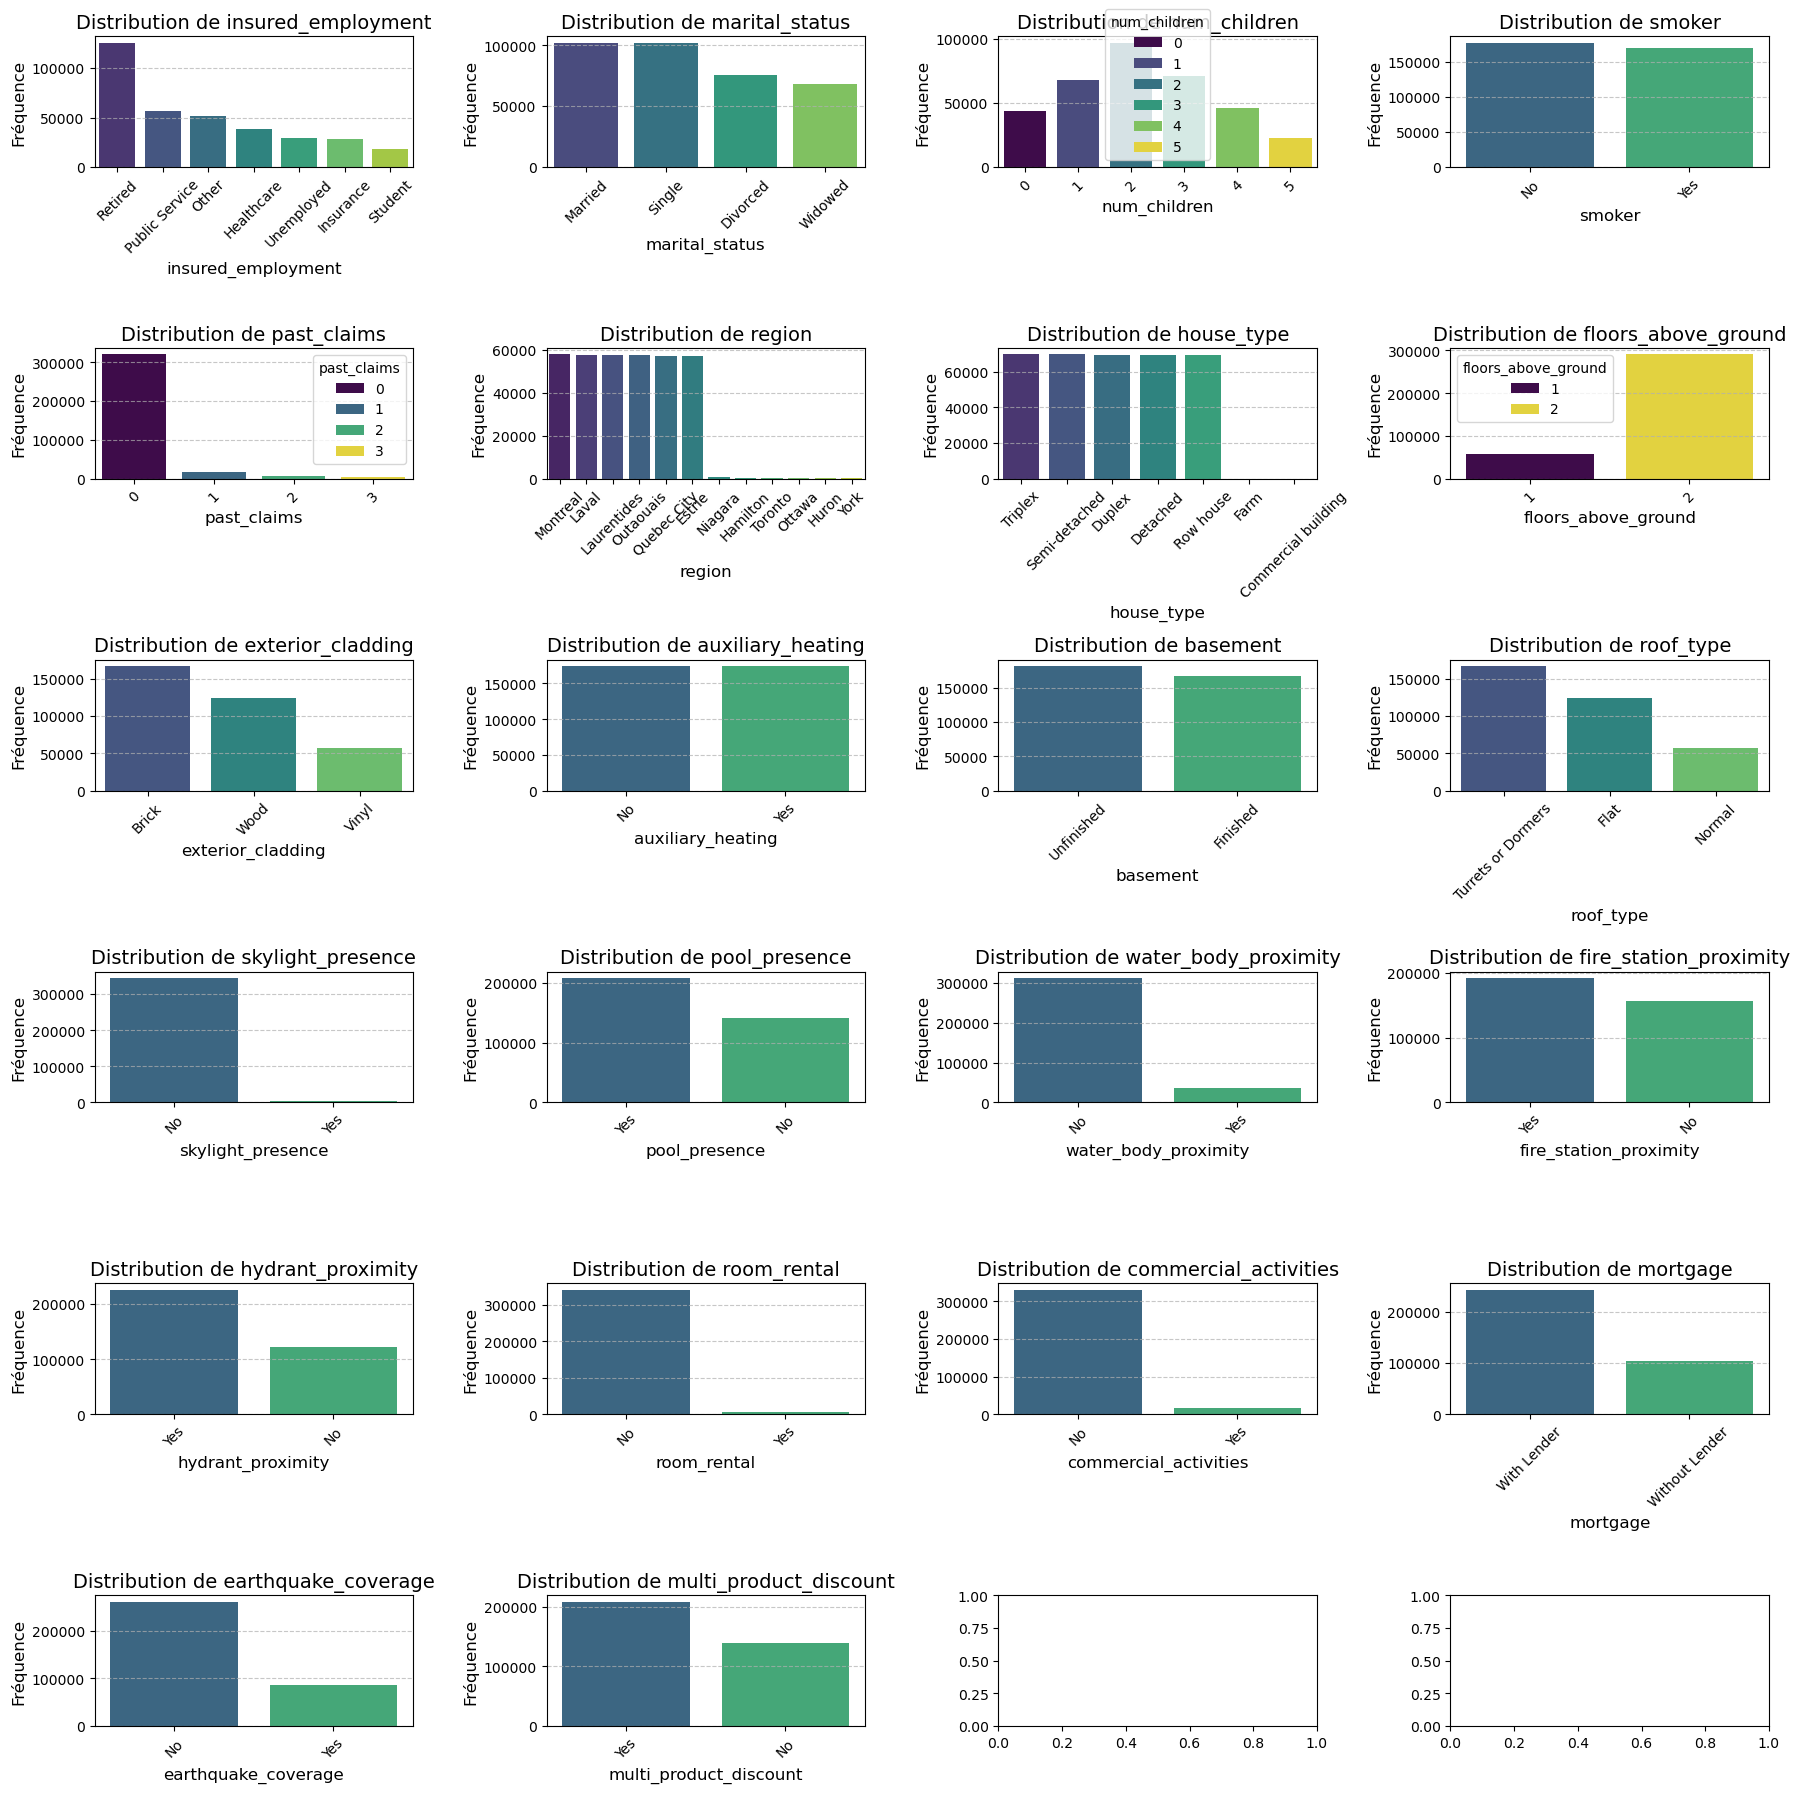

In [38]:
# Liste des colonnes à visualiser
columns_to_plot = [
    'insured_employment','marital_status','num_children', 'smoker', 'past_claims', 'region', 
     'house_type', 'floors_above_ground', 'exterior_cladding', "auxiliary_heating",
     'basement', 'roof_type', 
    'skylight_presence', 'pool_presence', 
    'water_body_proximity', 'fire_station_proximity', 
    'hydrant_proximity', 'room_rental', 
    'commercial_activities', 'mortgage', 
     "earthquake_coverage", "multi_product_discount"
]

# Création de la figure avec des sous-graphiques
fig, axes = plt.subplots(nrows=6, ncols=4, figsize=(18, 18))
axes = axes.flatten()  # Aplatir pour une itération facile

# Boucle à travers les colonnes et les axes pour créer des bar plots
for i, col in enumerate(columns_to_plot):
    # Comptage des valeurs uniques
    count_data = df[col].value_counts().reset_index()
    count_data.columns = [col, 'Count']
    
    # Création du bar plot
    sns.barplot(x=col, y='Count', data=count_data, ax=axes[i], palette='viridis', hue=col)
    axes[i].set_title(f'Distribution de {col}', fontsize=14)
    axes[i].set_xlabel(col, fontsize=12)
    axes[i].set_ylabel('Fréquence', fontsize=12)
    axes[i].grid(axis='y', linestyle='--', alpha=0.7)
    axes[i].tick_params(axis='x', rotation=45)  # Rotation pour une meilleure lisibilité

# Ajustement de l'espacement entre les sous-graphiques
plt.tight_layout()

L'analyse exploratoire des données catégorielles ci-dessous ne décèle pas de données abérrantes.
- insured_employment
- marital_status
- num_children
- smoker
- past_claims
- region
- house_type
- floors_above_ground
- exterior_cladding
- auxiliary_heating
- basement
- roof_type
- skylight_presence
- pool_presence
- water_body_proximity
- fire_station_proximity
- hydrant_proximity
- room_rental
- commercial_activities
- mortgage
- earthquake_coverage
- multi_product_discount


Explorons maintenant les données numériques 

- **earned_exposure**

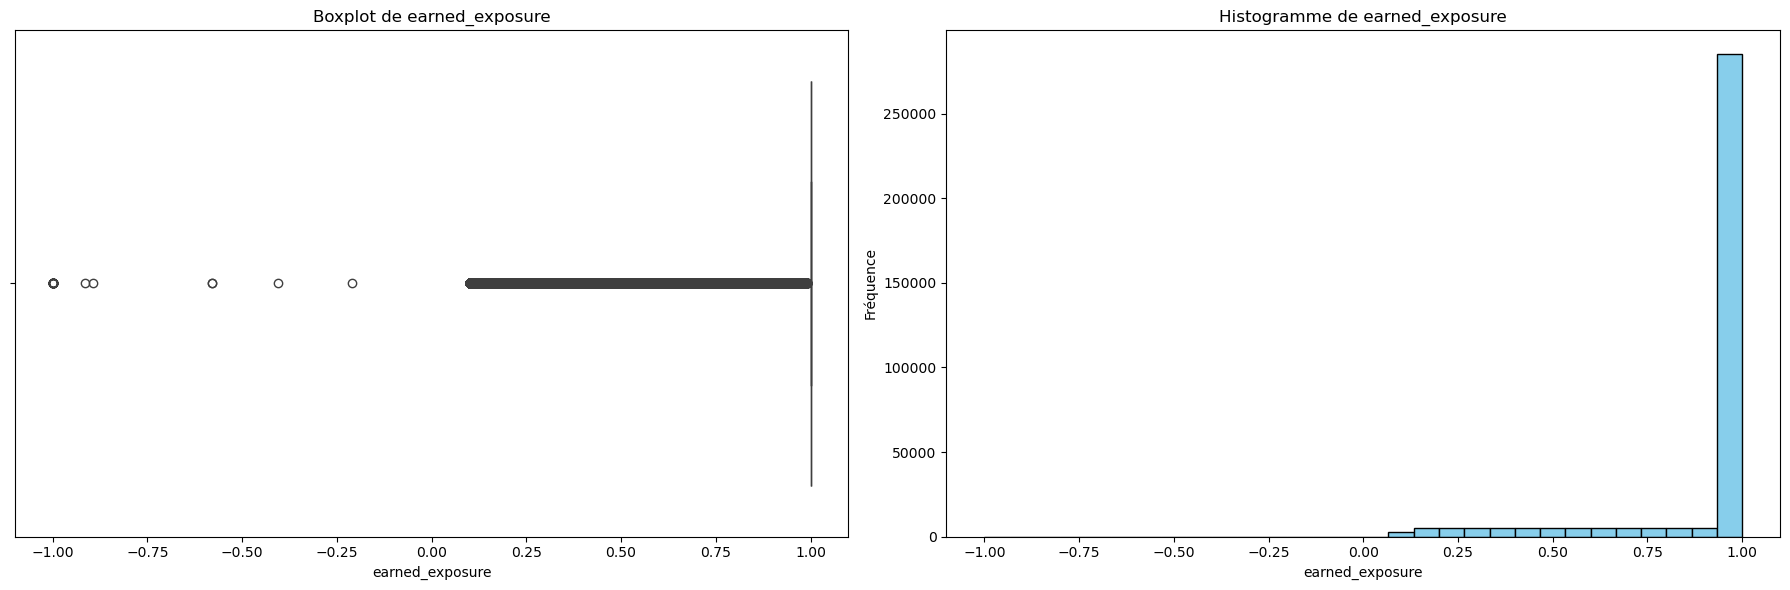

In [39]:
# Créer la figure avec des sous-graphiques
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(18, 6))
axes = axes.flatten()  # Aplatir pour une itération facile

# Boxplot
sns.boxplot(x='earned_exposure', data=df, ax=axes[0])
axes[0].set_title('Boxplot de earned_exposure')

# Histogramme
axes[1].hist(df['earned_exposure'], bins=30, color='skyblue', edgecolor='black')
axes[1].set_title('Histogramme de earned_exposure')
axes[1].set_xlabel('earned_exposure')
axes[1].set_ylabel('Fréquence')



# Ajuster l'espacement entre les sous-graphiques
plt.tight_layout()

On note des taux d'exposition négatif or la variable d'exposition est positive.

In [40]:
df['earned_exposure'] = df['earned_exposure'].abs()

- **policy_issue_year**

In [41]:
df["policy_issue_year"].value_counts()

policy_issue_year
2022    69938
2019    69803
2021    69696
2020    69441
2023    69384
Name: count, dtype: int64

Tout semble être bon pour cette variable. Il semble y avoir une répartition équitable entre les années

- **residence_stability**

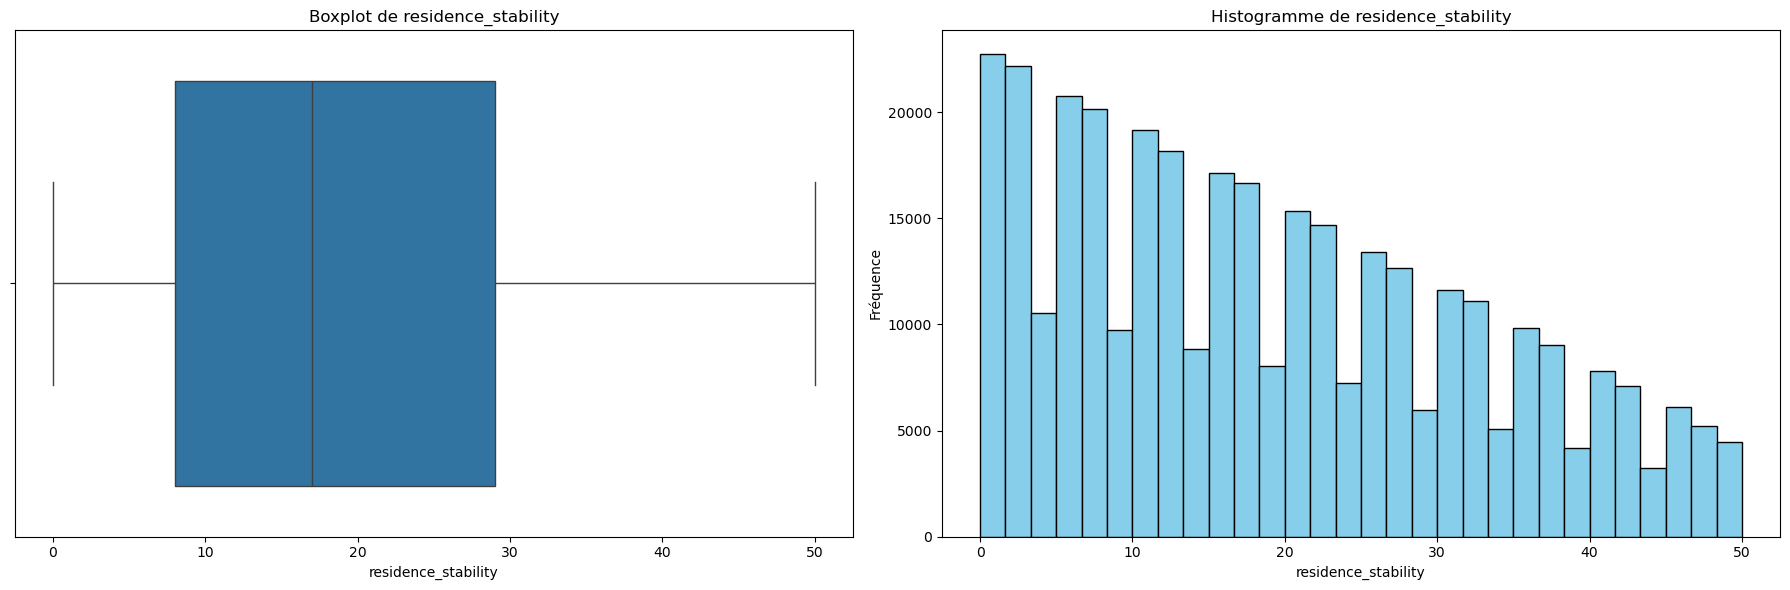

In [42]:
# Créer la figure avec des sous-graphiques
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(18, 6))
axes = axes.flatten()  # Aplatir pour une itération facile

# Boxplot
sns.boxplot(x='residence_stability', data=df, ax=axes[0])
axes[0].set_title('Boxplot de residence_stability')

# Histogramme
axes[1].hist(df['residence_stability'], bins=30, color='skyblue', edgecolor='black')
axes[1].set_title('Histogramme de residence_stability')
axes[1].set_xlabel('residence_stability')
axes[1].set_ylabel('Fréquence')


# Ajuster l'espacement entre les sous-graphiques
plt.tight_layout()

In [81]:
df['residence_stability'].value_counts()

residence_stability
0     11464
1     11269
2     11170
3     11005
4     10562
5     10407
6     10388
7     10192
8      9982
10     9843
9      9724
11     9350
12     9186
13     8985
14     8835
15     8680
17     8553
16     8468
18     8118
19     8058
20     7827
21     7523
22     7345
23     7343
24     7219
25     6843
26     6555
27     6444
28     6229
29     5963
30     5916
31     5714
32     5615
33     5482
34     5082
35     4988
36     4847
37     4526
38     4518
39     4158
40     3986
41     3814
42     3667
43     3420
44     3236
45     3101
46     2996
47     2772
48     2430
49     2323
50     2141
Name: count, dtype: int64

Tout semble être bon 

- **roof_year**

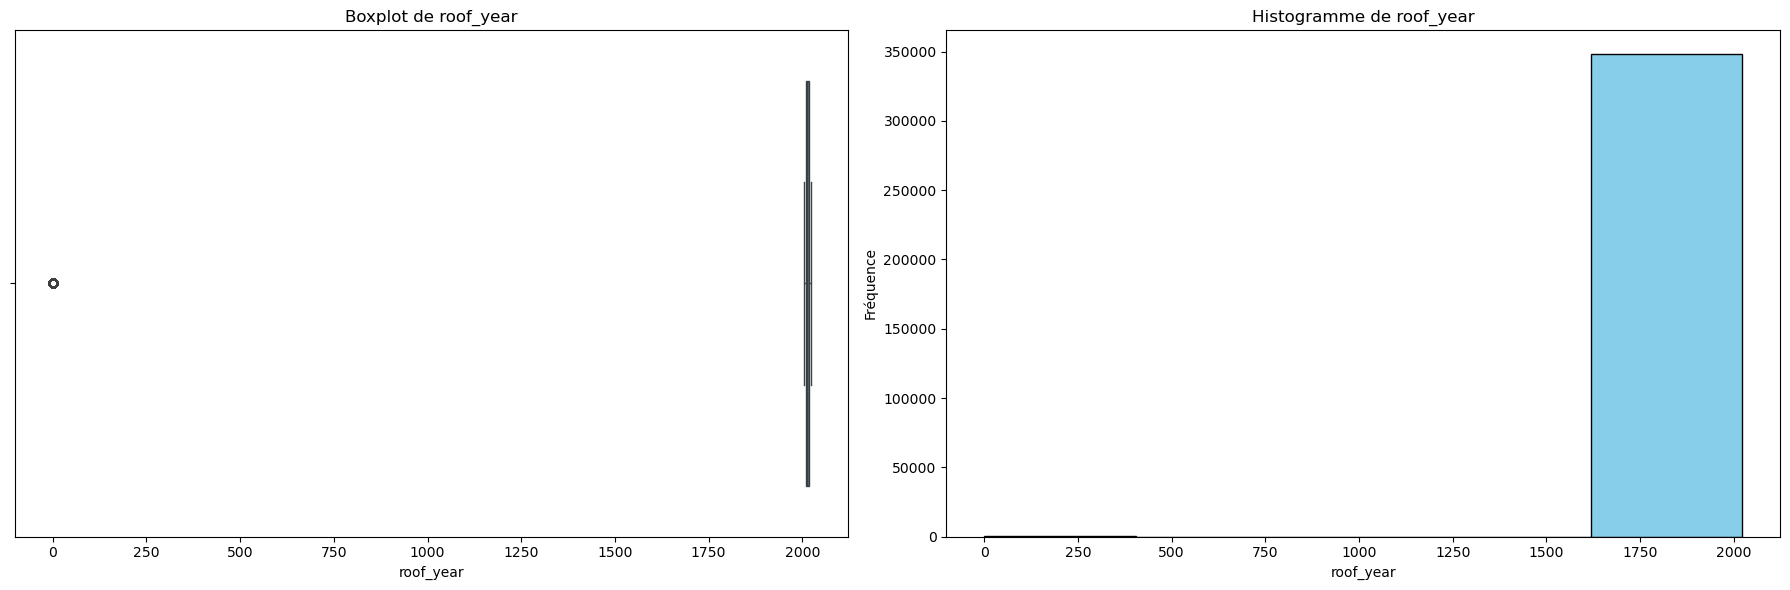

In [43]:
# Créer la figure avec des sous-graphiques
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(18, 6))
axes = axes.flatten()  # Aplatir pour une itération facile

# Boxplot
sns.boxplot(x='roof_year', data=df, ax=axes[0])
axes[0].set_title('Boxplot de roof_year')

# Histogramme
axes[1].hist(df['roof_year'], bins=5, color='skyblue', edgecolor='black')
axes[1].set_title('Histogramme de roof_year')
axes[1].set_xlabel('roof_year')
axes[1].set_ylabel('Fréquence')


# Ajuster l'espacement entre les sous-graphiques
plt.tight_layout()

In [44]:
sum(df['roof_year']==0)/len(df) * 100

0.09073628475113564

On observe des observation égale à 0 et représente moins de 1% de nos données. roof_year représente l'année de construction ou de rénovation de la toiture de la maison assurée. Ici, on peut penser que 0 était une erreur de saisie pour signifier qu'il n'y a pas eu de rénovation de la toiture donc par conséquent la variable serait égale à l'année de construction de la maison. 

In [45]:
df.loc[df['roof_year'] == 0, "roof_year"] = df.loc[df['roof_year'] == 0, "construction_year"]

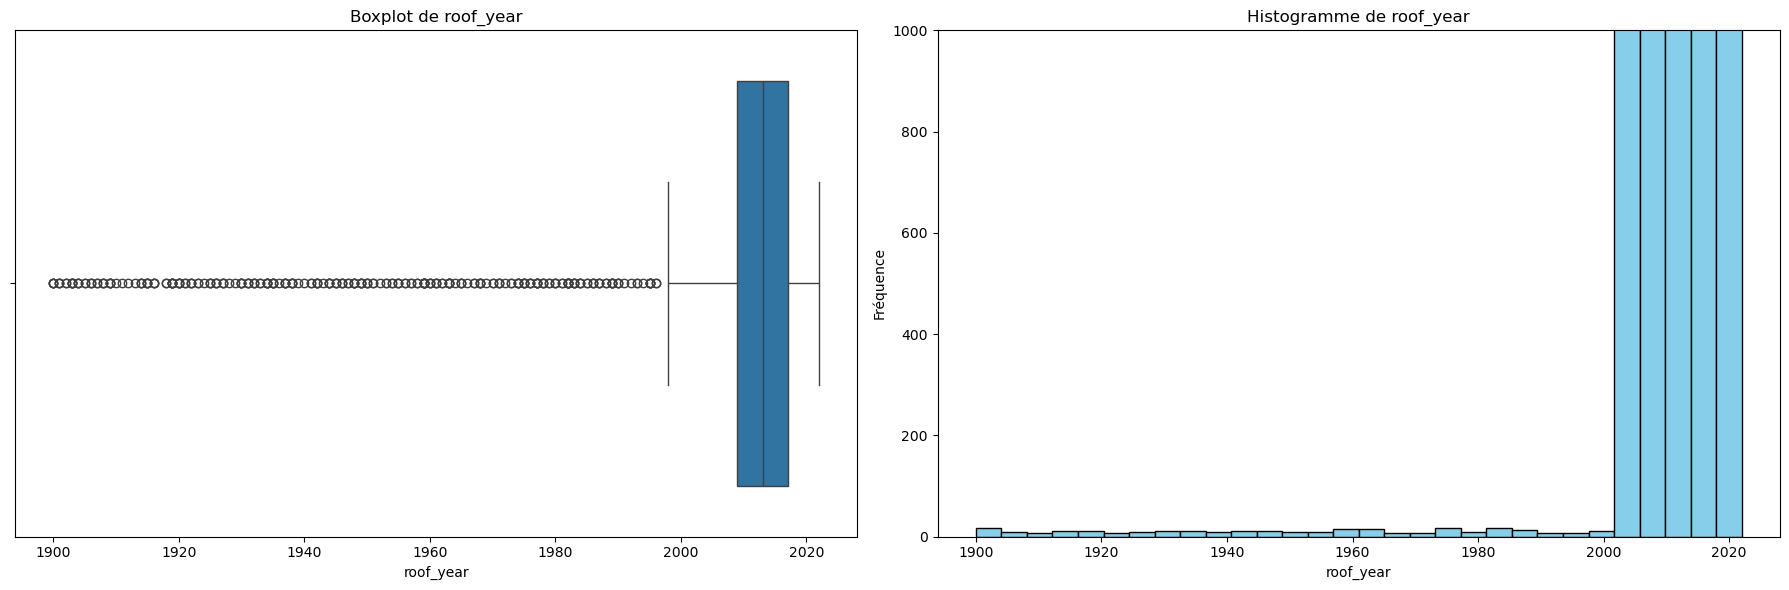

In [46]:
#### Créer la figure avec des sous-graphiques
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(18, 6))
axes = axes.flatten()  # Aplatir pour une itération facile

# Boxplot
sns.boxplot(x='roof_year', data=df, ax=axes[0])
axes[0].set_title('Boxplot de roof_year')

# Histogramme
axes[1].hist(df['roof_year'], bins=30, color='skyblue', edgecolor='black')
axes[1].set_title('Histogramme de roof_year')
axes[1].set_xlabel('roof_year')
axes[1].set_ylabel('Fréquence')
axes[1].set_ylim(0, 1000)


# Ajuster l'espacement entre les sous-graphiques
plt.tight_layout()

In [47]:
df['roof_year'].value_counts()

roof_year
2017    23801
2014    23771
2018    23742
2009    23689
2011    23661
        ...  
1912        1
1928        1
1992        1
1911        1
1936        1
Name: count, Length: 121, dtype: int64

- **credit_score**

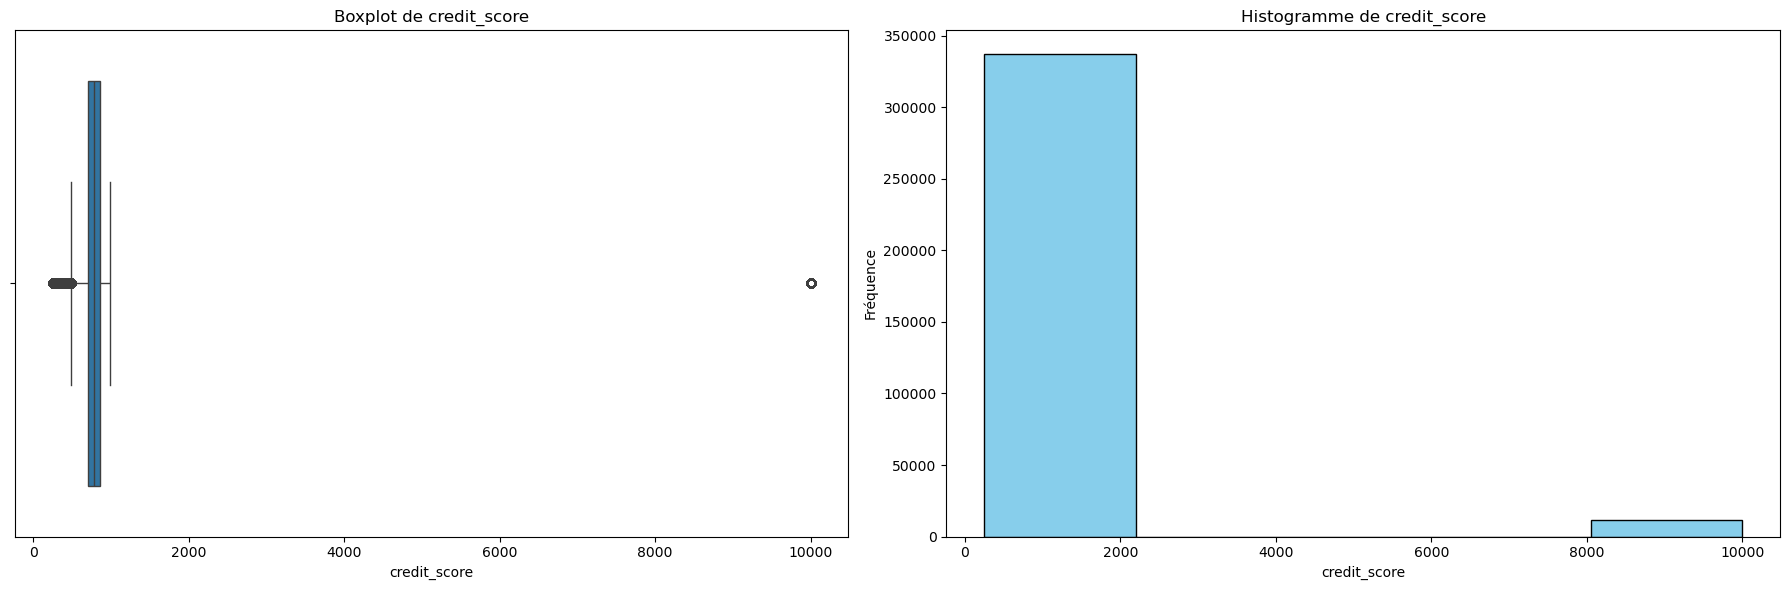

In [48]:
# Créer la figure avec des sous-graphiques
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(18, 6))
axes = axes.flatten()  # Aplatir pour une itération facile

# Boxplot
sns.boxplot(x='credit_score', data=df, ax=axes[0])
axes[0].set_title('Boxplot de credit_score')

# Histogramme
axes[1].hist(df['credit_score'], bins=5, color='skyblue', edgecolor='black')
axes[1].set_title('Histogramme de credit_score')
axes[1].set_xlabel('credit_score')
axes[1].set_ylabel('Fréquence')


# Ajuster l'espacement entre les sous-graphiques
plt.tight_layout()

On note l'existence de cotes de crédit  supérieures à 1000. On choisit la médiance pour imputer les cotes de crédits supérieures à 1000.

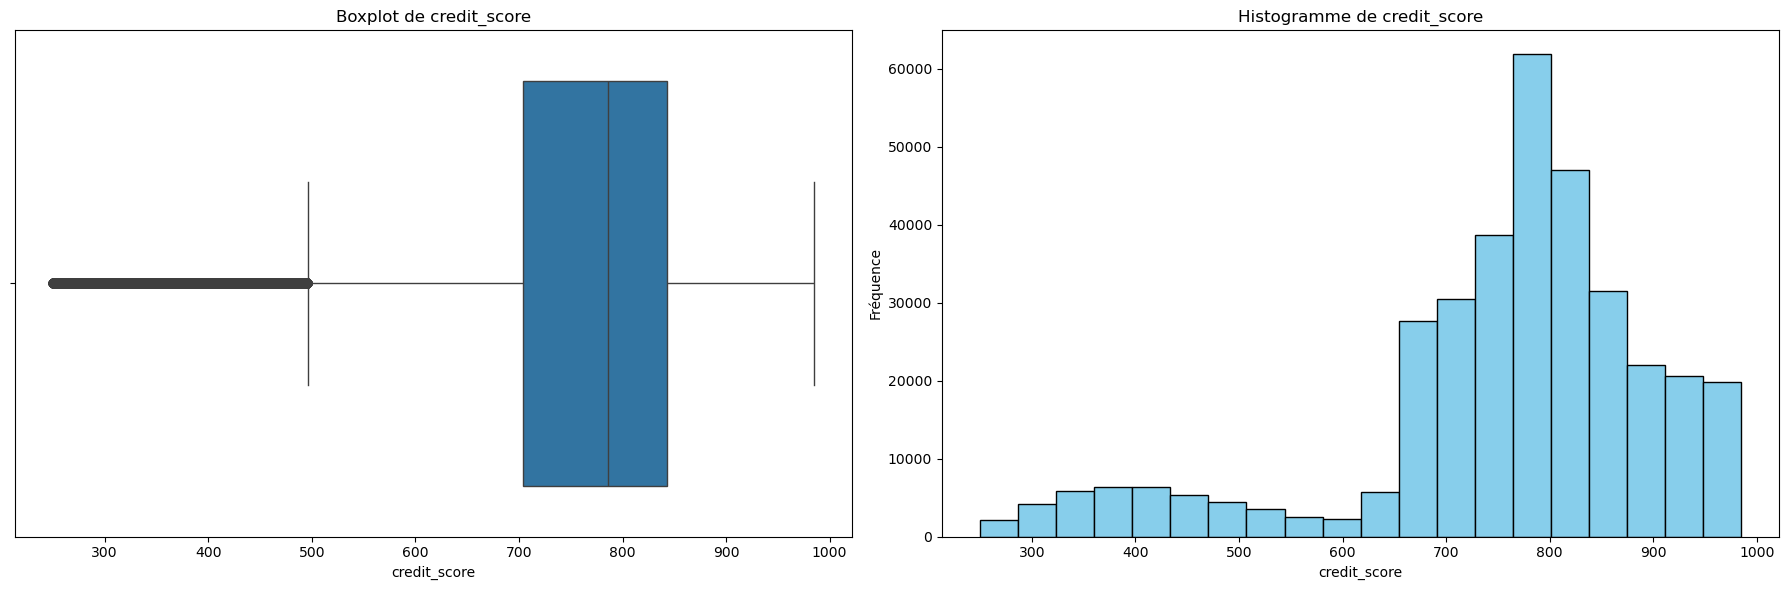

In [49]:
df['credit_score'] = df['credit_score'].abs()

df.loc[df['credit_score'] > 1000, 'credit_score'] = df["credit_score"].median()

# Créer la figure avec des sous-graphiques
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(18, 6))
axes = axes.flatten()  # Aplatir pour une itération facile

# Boxplot
sns.boxplot(x='credit_score', data=df, ax=axes[0])
axes[0].set_title('Boxplot de credit_score')

# Histogramme
axes[1].hist(df['credit_score'], bins=20, color='skyblue', edgecolor='black')
axes[1].set_title('Histogramme de credit_score')
axes[1].set_xlabel('credit_score')
axes[1].set_ylabel('Fréquence')


# Ajuster l'espacement entre les sous-graphiques
plt.tight_layout()

- **reconstruction_cost**

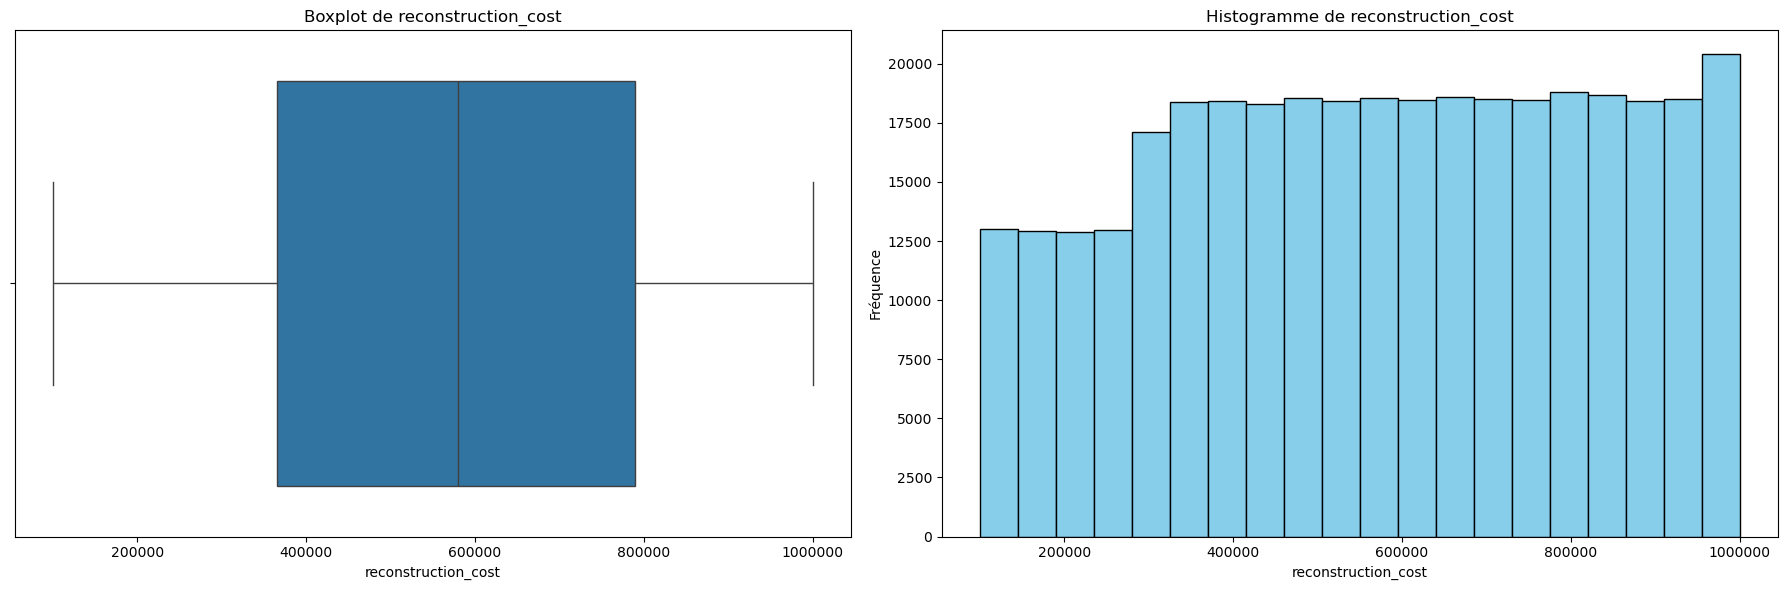

In [50]:
# Créer la figure avec des sous-graphiques
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(18, 6))
axes = axes.flatten()  # Aplatir pour une itération facile

# Boxplot
sns.boxplot(x='reconstruction_cost', data=df, ax=axes[0])
axes[0].set_title('Boxplot de reconstruction_cost')
axes[0].get_xaxis().set_major_formatter(FuncFormatter(lambda x, _: f'{x:.0f}'))

# Histogramme
axes[1].hist(df['reconstruction_cost'], bins=20, color='skyblue', edgecolor='black')
axes[1].set_title('Histogramme de reconstruction_cost')
axes[1].set_xlabel('reconstruction_cost')
axes[1].set_ylabel('Fréquence')
axes[1].get_xaxis().set_major_formatter(FuncFormatter(lambda x, _: f'{x:.0f}'))

# Ajuster l'espacement entre les sous-graphiques
plt.tight_layout()

Pas de problèmes détectés.

- **client_start_year** et **oldest_insured_year_birth**

In [51]:
df["client_start_year"].value_counts()

client_start_year
2019    33766
2018    32744
2017    32077
2016    31366
2015    30703
2014    29640
2013    28634
2020    27604
2012    22829
2021    20867
2011    16864
2022    14273
2010    10998
2023     7073
2009     5375
0        3449
Name: count, dtype: int64

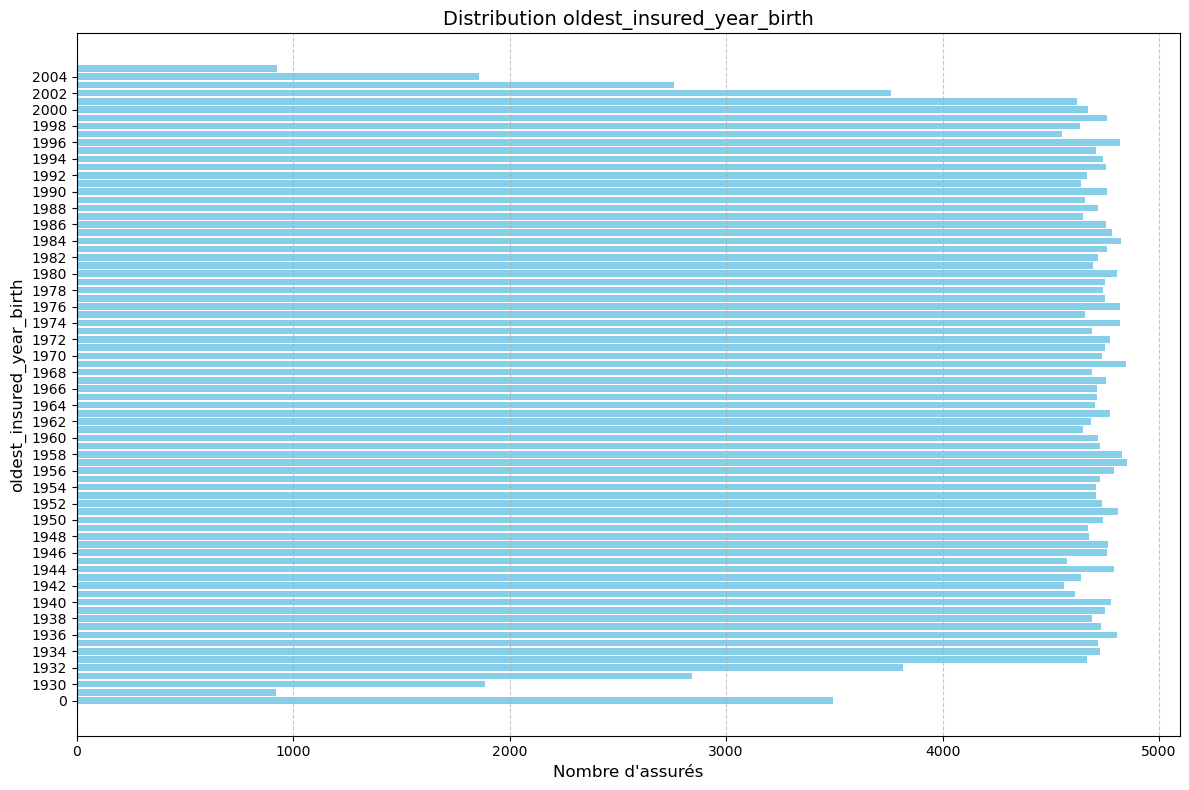

In [52]:
# Calculer la répartition des années de naissance
count_df = df['oldest_insured_year_birth'].value_counts().reset_index()
count_df.columns = ['Year', 'Count']

# Trier par année de naissance (Year) de manière croissante
count_df = count_df.sort_values(by='Year', ascending=True)

# Tracer le graphique à barres horizontal
plt.figure(figsize=(12, 8))  # Augmenter la taille de la figure
plt.barh(count_df['Year'].astype(str), count_df['Count'], color='skyblue')
plt.xlabel('Nombre d\'assurés', fontsize=12)
plt.ylabel('oldest_insured_year_birth', fontsize=12)
plt.title('Distribution oldest_insured_year_birth', fontsize=14)

# Réduire la taille de la police des étiquettes
plt.yticks(fontsize=10)

# Afficher une étiquette sur deux
plt.yticks(count_df['Year'].astype(str)[::2], fontsize=10)  # Affiche seulement une sur deux

plt.tight_layout()  # Ajustement automatique des marges
plt.grid(axis='x', linestyle='--', alpha=0.7)

Ici, la méthode d'imputation des valeurs égales à 0 sera basée une imputation itérative.L'idée derrière l'imputation par régression itérative est de traiter les valeurs manquantes dans nos données en les remplaçant par des valeurs estimées à l'aide d'un modèle de régression. Lorsqu'une valeur est manquante pour une caractéristique donnée, cette valeur est estimée en fonction des autres caractéristiques présentes dans la même ligne. Chaque variable est modélisée comme une régression linéaire des autres variables qui ne sont pas manquantes. L'idée est d'utiliser les autres colonnes comme prédicteurs pour estimer les valeurs manquantes. Cette procédure est répétée de manière itérative jusqu'à ce que les estimations convergent (c'est-à-dire qu'elles ne changent plus de manière significative entre les itérations).

In [53]:
df['client_start_year'] = df['client_start_year'].replace(0, np.nan)
df['oldest_insured_year_birth'] = df['oldest_insured_year_birth'].replace(0, np.nan)

In [54]:
# Sélectionner les colonnes pertinentes à imputer
columns_to_impute = ['oldest_insured_year_birth', 'client_start_year']

# Créer l'imputeur
imputer = IterativeImputer(max_iter=42, random_state=0)

# Appliquer l'imputation
df[columns_to_impute] = imputer.fit_transform(df[columns_to_impute])

df[columns_to_impute] = df[columns_to_impute].round().astype(int)

In [55]:
df["client_start_year"].value_counts()

client_start_year
2019    33766
2017    33332
2016    33263
2018    32744
2015    31000
2014    29640
2013    28634
2020    27604
2012    22829
2021    20867
2011    16864
2022    14273
2010    10998
2023     7073
2009     5375
Name: count, dtype: int64

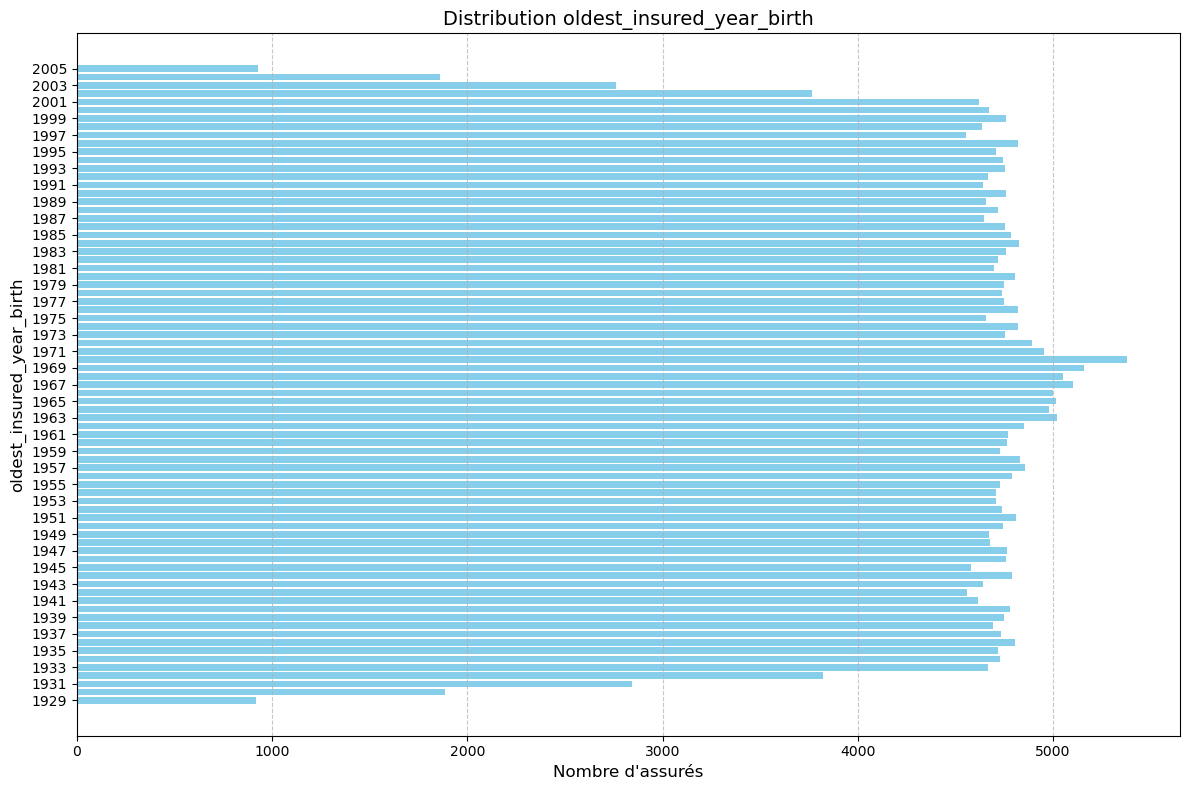

In [56]:
# Calculer la répartition des années de naissance
count_df = df['oldest_insured_year_birth'].value_counts().reset_index()
count_df.columns = ['Year', 'Count']

# Trier par année de naissance (Year) de manière croissante
count_df = count_df.sort_values(by='Year', ascending=True)

# Tracer le graphique à barres horizontal
plt.figure(figsize=(12, 8))  # Augmenter la taille de la figure
plt.barh(count_df['Year'].astype(str), count_df['Count'], color='skyblue')
plt.xlabel('Nombre d\'assurés', fontsize=12)
plt.ylabel('oldest_insured_year_birth', fontsize=12)
plt.title('Distribution oldest_insured_year_birth', fontsize=14)

# Réduire la taille de la police des étiquettes
plt.yticks(fontsize=10)

# Afficher une étiquette sur deux
plt.yticks(count_df['Year'].astype(str)[::2], fontsize=10)  # Affiche seulement une sur deux

plt.tight_layout()  # Ajustement automatique des marges
plt.grid(axis='x', linestyle='--', alpha=0.7)

In [57]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 348262 entries, 1 to 350000
Data columns (total 39 columns):
 #   Column                     Non-Null Count   Dtype  
---  ------                     --------------   -----  
 0   client_start_year          348262 non-null  int64  
 1   oldest_insured_year_birth  348262 non-null  int64  
 2   insured_employment         348262 non-null  object 
 3   credit_score               348262 non-null  int64  
 4   marital_status             348262 non-null  object 
 5   num_children               348262 non-null  int64  
 6   smoker                     348262 non-null  object 
 7   past_claims                348262 non-null  int64  
 8   region                     348262 non-null  object 
 9   construction_year          348262 non-null  float64
 10  house_type                 348262 non-null  object 
 11  reconstruction_cost        348262 non-null  int64  
 12  floors_above_ground        348262 non-null  int64  
 13  exterior_cladding          348262 

Sur nos 350000 observations il nous reste 348262 observations

In [60]:
# Réinitialiser l'index et exporter en CSV
df_reset = df.reset_index()
df_reset.to_csv('data/home_data_cleaned.csv')

In [59]:
percent_missing(df)

Series([], dtype: float64)